# Importance Sampling for Loss Estimation: Variance Analysis


We want to find parameters $\alpha$ that minimise the expected squared error:

$$\arg\min_\alpha\; \mathbb{E}\bigl[(\theta - f_\alpha(Y))^2\bigr] = L$$

**Naive Monte Carlo estimate** — draw $(\theta^{(i)}, Y^{(i)}) \sim \pi(\theta)$:

$$\hat{L}^{MC} = \frac{1}{N}\sum_{i=1}^{N}\bigl(\theta^{(i)} - f_\alpha(Y^{(i)})\bigr)^2$$

**Importance sampling estimate** — draw from proposal $q$ and reweight:

$$\hat{L}_\alpha^{IS} = \frac{1}{N}\sum_{i=1}^{N} w_q(\theta^{(i)})\;\bigl(\theta^{(i)} - f_\alpha(Y^{(i)})\bigr)^2, \qquad w_q(\theta) = \frac{\pi(\theta)}{q(\theta)}$$

idea:

$$\text{Var}\!\bigl(\hat{L}^{IS}_\alpha\bigr) < \text{Var}\!\bigl(\hat{L}^{MC}\bigr)$$

IS is unbiased, but the weights $w_q$ can be wildly uneven. If the proposal $q$ is poorly chosen, $\hat{L}^{IS}$ becomes a **noisier** estimate even though it's still correct in expectation. This notebook investigates empirically whether our Beta proposals help or hurt.


$$\text{Var}(\hat{L}^{IS}) = \frac{1}{N}\,\text{Var}_q\!\bigl[w(\theta)\cdot\ell(\theta,Y)\bigr]$$

Compared to the MC baseline:

$$\text{Var}(\hat{L}^{MC}) = \frac{1}{N}\,\text{Var}_\pi\!\bigl[\ell(\theta,Y)\bigr]$$

IS reduces variance when the reweighted loss $w\cdot\ell$ is **less variable** than $\ell$ alone — i.e., when the proposal concentrates samples where the loss is large, effectively "flattening" the integrand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


In [2]:
# Configuration
A = 5.0
T = 64

ALPHA_VALUES = [1.0, 0.5, 0.3, 0.1]

# Training config (for reference model)
N_EPOCHS = 48
N_BATCHES_PER_EPOCH = 48
TRAINING_BATCH_SIZE = 64

# Variance experiment config
K = 500               # independent loss estimates per condition
BATCH_SIZES = [32, 64, 128, 256, 512]  # for scaling analysis
BETA_SIGMA = 1
BASE_SEED = 42

print("Configuration loaded")

Configuration loaded


In [3]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = 2 * rho_tilde - 1
    sigma = A * sigma_tilde
    rho = torch.tensor(rho, dtype=torch.float32, device=device)
    sigma = torch.tensor(sigma, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    q_theta = q_rho * q_sigma
    p_theta = 1.0 / (2 * A)
    return p_theta / q_theta

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))

    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("All core functions loaded")

All core functions loaded


In [4]:
# Theoretical ESS for each proposal (before seeing any model)
print("="*60)
print("THEORETICAL ESS (proposal-level, no model needed)")
print("="*60)

set_seed(0)
N_th = 50_000

theoretical_ess = {}
for alpha in ALPHA_VALUES:
    rho, sigma = sample_from_proposal(N_th, alpha, alpha, BETA_SIGMA, A)
    w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
    w_norm = w / w.sum()
    ess = 1.0 / np.sum(w_norm**2)
    ess_frac = ess / N_th
    theoretical_ess[alpha] = ess_frac

    print(f"alpha={alpha}: ESS = {ess:.0f}/{N_th} = {ess_frac:.4f}")
    print(f"   w: mean={w.mean():.3f}, std={w.std():.3f}, max={w.max():.2f}, "
          f"min={w.min():.5f}, max/min={w.max()/max(w.min(),1e-10):.0f}")


THEORETICAL ESS (proposal-level, no model needed)
alpha=1.0: ESS = 50000/50000 = 1.0000
   w: mean=1.000, std=0.000, max=1.00, min=1.00000, max/min=1
alpha=0.5: ESS = 30450/50000 = 0.6090
   w: mean=1.002, std=0.803, max=3.14, min=0.00000, max/min=31398321447
alpha=0.3: ESS = 15379/50000 = 0.3076
   w: mean=1.009, std=1.514, max=7.57, min=0.00000, max/min=75740992446
alpha=0.1: ESS = 2406/50000 = 0.0481
   w: mean=0.978, std=4.351, max=56.44, min=0.00000, max/min=564397931156


## C. Train Reference Model

We train **one** model using uniform sampling ($\alpha = 1.0$). This gives us a fixed $f$ to evaluate. The variance experiment then asks: for this fixed model, how does the choice of proposal affect the precision of our loss estimate?

In [5]:
# Train one reference model (uniform, alpha=1.0)
def train_model(n_epochs, n_batches, batch_size, device, seed=42):
    set_seed(seed)
    model = GRUPosteriorEstimator(
        input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

    for epoch in range(n_epochs):
        model.train()
        for _ in range(n_batches):
            rho = torch.empty(batch_size, device=device).uniform_(-1, 1)
            sigma = torch.empty(batch_size, device=device).uniform_(0, A)
            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue
            theta_pred = model(x)
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue
            loss = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).mean()
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    return model

print("Training reference model...")
t0 = time.time()
ref_model = train_model(N_EPOCHS, N_BATCHES_PER_EPOCH, TRAINING_BATCH_SIZE, device)
ref_model.eval()
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

# Quick sanity check
set_seed(99)
rho_check = torch.empty(1024, device=device).uniform_(-1, 1)
sigma_check = torch.empty(1024, device=device).uniform_(0, A)
x_check = simulate_ar1_batch(rho_check, sigma_check, T, 1024, device=device)
with torch.no_grad():
    pred_check = ref_model(x_check)
    mse_check = ((pred_check - torch.stack([rho_check, sigma_check], dim=1))**2).mean().item()
print(f"Reference model MSE on 1024 uniform samples: {mse_check:.4f}")

Training reference model...
Done in 35.8s
Reference model MSE on 1024 uniform samples: 0.0889


## D. Main Experiment: Loss Estimator Variance

For the **fixed** reference model $f$, we draw $K = 2000$ independent batches of size $N = 128$ under each proposal $q_\alpha$. Each batch yields one estimate of $L = \mathbb{E}[(\theta - f(Y))^2]$.

We compare three weight-handling strategies:
1. **Raw IS**: $\hat{L} = \frac{1}{N}\sum w_i \ell_i$ (unbiased, potentially high variance)
2. **Clipped IS**: clamp $w \in [0.1, 10]$ then normalise (biased, lower variance — what we use in training)
3. **Self-normalised IS**: $\hat{L} = \sum \bar{w}_i \ell_i$ where $\bar{w}_i = w_i / \sum w_j$ (biased, often lower variance)

In [6]:
# Main experiment: K independent loss estimates per (alpha, weighting method)
N = 128
print(f"Drawing K={K} independent batches of size N={N} for each proposal...")
print("This measures the variance of the loss estimator under different proposals.\n")

loss_estimates = {}   # [alpha][method] = array of K values
weight_stats = {}     # [alpha] = dict of weight statistics

set_seed(0)

for alpha in ALPHA_VALUES:
    loss_estimates[alpha] = {'raw': [], 'clipped': [], 'self_norm': []}
    w_means, w_stds, w_maxs, batch_ess = [], [], [], []

    for k in range(K):
        # Sample from proposal
        rho, sigma = sample_from_proposal(N, alpha, alpha, BETA_SIGMA, A, device=device)
        w_raw = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
        w_raw_t = torch.tensor(w_raw, dtype=torch.float32, device=device)

        # Simulate and predict
        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            theta_pred = ref_model(x)
        losses = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)

        # 1. Raw IS estimate
        raw_est = (w_raw_t * losses).mean().item()
        loss_estimates[alpha]['raw'].append(raw_est)

        # 2. Clipped IS (as used in training)
        w_clip = torch.clamp(w_raw_t, min=0.1, max=10.0)
        w_clip_norm = w_clip / w_clip.sum()
        clip_est = (w_clip_norm * losses).sum().item()
        loss_estimates[alpha]['clipped'].append(clip_est)

        # 3. Self-normalised IS
        w_sn = w_raw_t / w_raw_t.sum()
        sn_est = (w_sn * losses).sum().item()
        loss_estimates[alpha]['self_norm'].append(sn_est)

        # Weight stats
        w_means.append(w_raw.mean())
        w_stds.append(w_raw.std())
        w_maxs.append(w_raw.max())
        wn = w_raw / w_raw.sum()
        batch_ess.append(1.0 / np.sum(wn**2))

    for m in loss_estimates[alpha]:
        loss_estimates[alpha][m] = np.array(loss_estimates[alpha][m])

    weight_stats[alpha] = {
        'mean_w': np.mean(w_means), 'std_w': np.mean(w_stds),
        'max_w': np.mean(w_maxs), 'ess': np.mean(batch_ess)}

    print(f"alpha={alpha}: done  (mean ESS={weight_stats[alpha]['ess']:.1f}/{N})")

print("\nAll estimates collected.")

Drawing K=500 independent batches of size N=128 for each proposal...
This measures the variance of the loss estimator under different proposals.

alpha=1.0: done  (mean ESS=128.0/128)
alpha=0.5: done  (mean ESS=78.2/128)
alpha=0.3: done  (mean ESS=39.6/128)
alpha=0.1: done  (mean ESS=7.2/128)

All estimates collected.


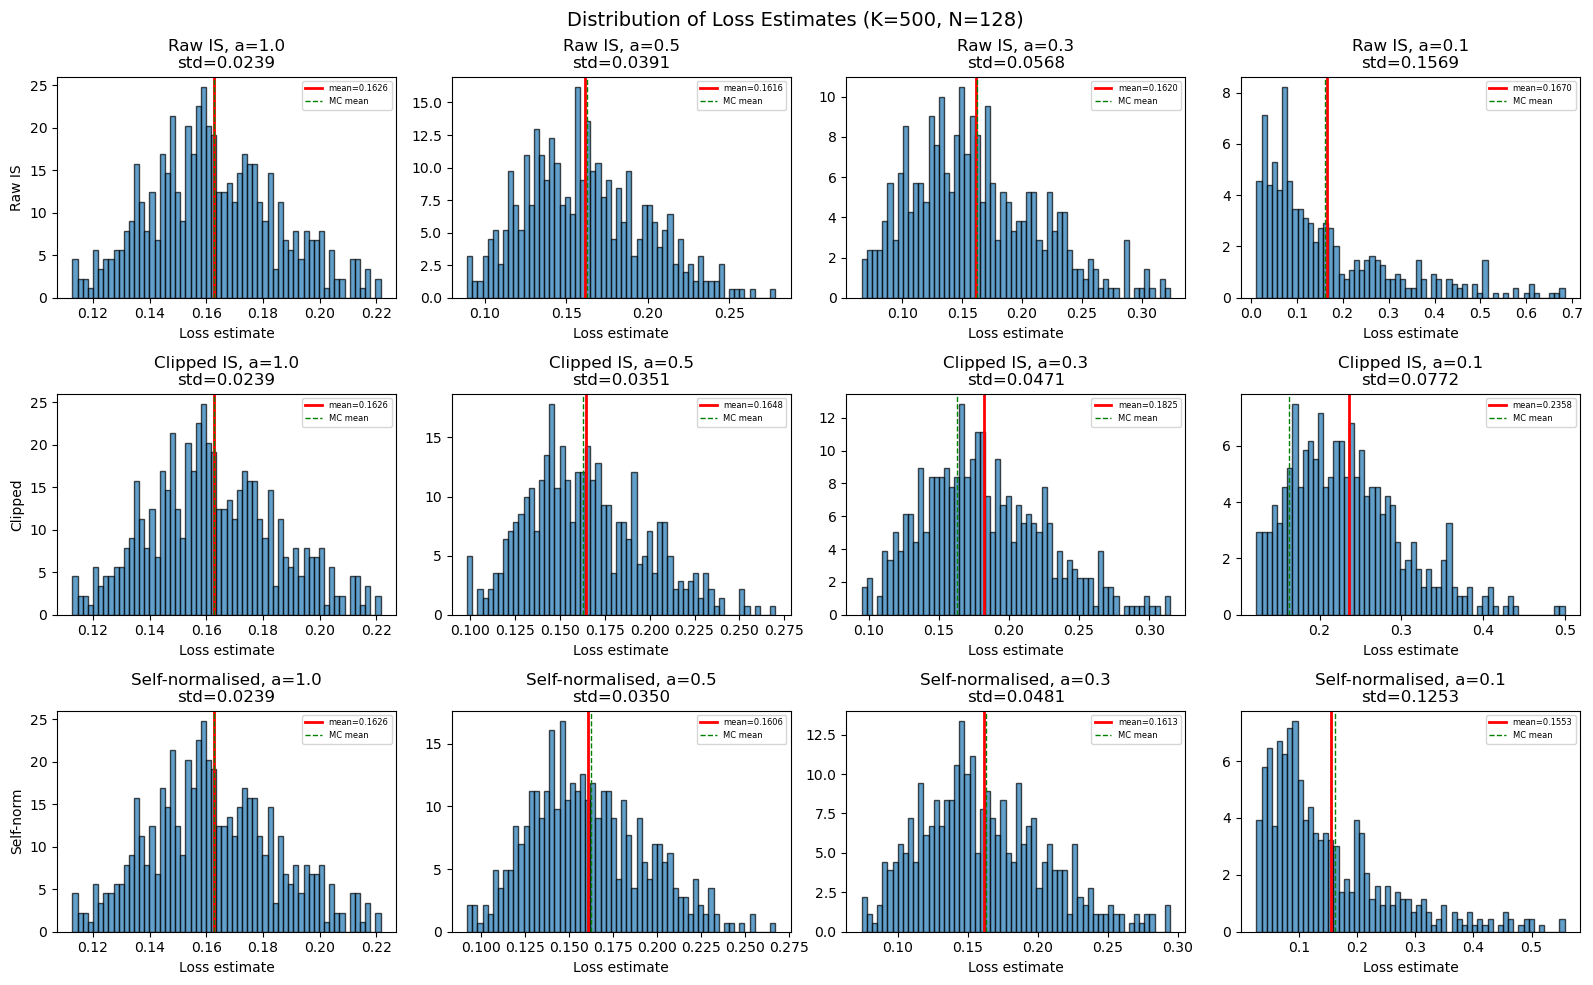

In [7]:
# Histograms of loss estimates
fig, axes = plt.subplots(3, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 10))
methods = ['raw', 'clipped', 'self_norm']
method_labels = ['Raw IS', 'Clipped IS', 'Self-normalised']

for mi, (method, label) in enumerate(zip(methods, method_labels)):
    for ai, alpha in enumerate(ALPHA_VALUES):
        est = loss_estimates[alpha][method]
        ax = axes[mi, ai]

        # Remove extreme outliers for plotting (keep 1st-99th percentile)
        lo, hi = np.percentile(est, [1, 99])
        mask = (est >= lo) & (est <= hi)

        ax.hist(est[mask], bins=60, alpha=0.7, edgecolor='black', density=True)
        ax.axvline(x=est.mean(), color='r', linestyle='-', linewidth=2, label=f'mean={est.mean():.4f}')
        ax.axvline(x=loss_estimates[1.0][method].mean(), color='green', linestyle='--',
                   linewidth=1, label='MC mean')
        ax.set_xlabel('Loss estimate')
        ax.set_title(f'{label}, a={alpha}\nstd={est.std():.4f}')
        ax.legend(fontsize=6)

axes[0, 0].set_ylabel('Raw IS'); axes[1, 0].set_ylabel('Clipped'); axes[2, 0].set_ylabel('Self-norm')
plt.suptitle(f'Distribution of Loss Estimates (K={K}, N={N})', fontsize=14)
plt.tight_layout(); plt.show()


VARIANCE OF LOSS ESTIMATOR (K=500 batches, N=128)

Method           Alpha    Mean         Std          Var            Var Ratio    ESS     
----------------------------------------------------------------------------------
Raw IS           a=1.0    0.1626       0.0239       0.000572       1.00         128.0   
Raw IS           a=0.5    0.1616       0.0391       0.001530       2.67         78.2    
Raw IS           a=0.3    0.1620       0.0568       0.003232       5.65         39.6    
Raw IS           a=0.1    0.1670       0.1569       0.024624       43.02        7.2     
Clipped IS       a=1.0    0.1626       0.0239       0.000572       1.00         128.0   
Clipped IS       a=0.5    0.1648       0.0351       0.001230       2.15         78.2    
Clipped IS       a=0.3    0.1825       0.0471       0.002220       3.88         39.6    
Clipped IS       a=0.1    0.2358       0.0772       0.005967       10.42        7.2     
Self-normalised  a=1.0    0.1626       0.0239       0.000572    

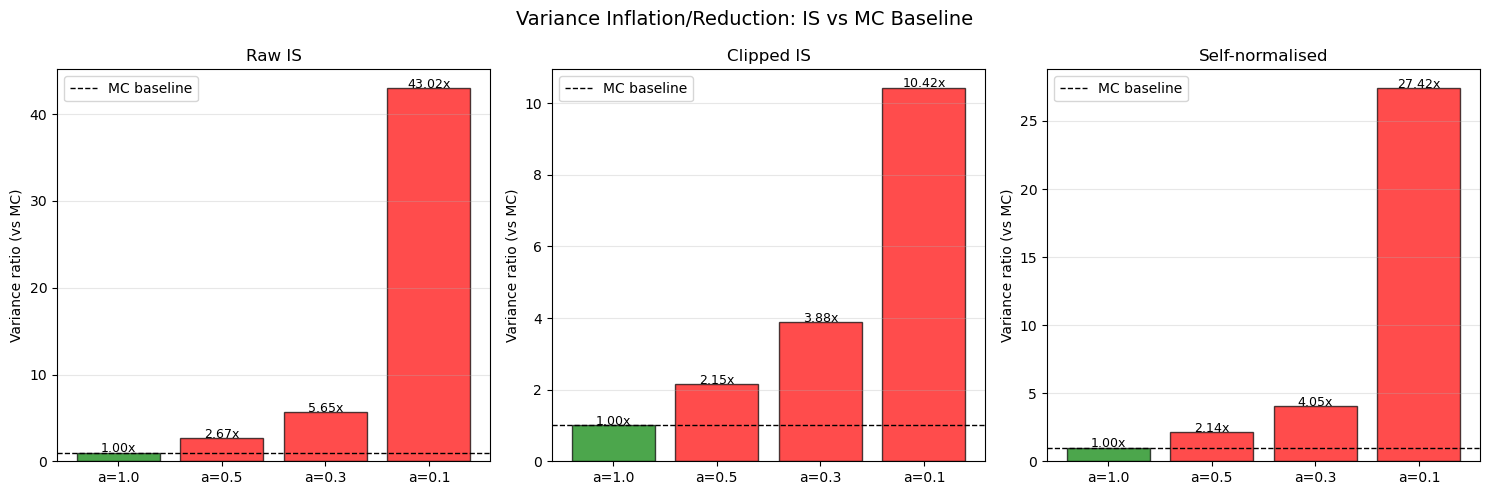

In [8]:
# Variance comparison table and bar chart
print("\n" + "="*90)
print(f"VARIANCE OF LOSS ESTIMATOR (K={K} batches, N={N})")
print("="*90)

print(f"\n{'Method':<16} {'Alpha':<8} {'Mean':<12} {'Std':<12} {'Var':<14} {'Var Ratio':<12} {'ESS':<8}")
print("-"*82)

ref_vars = {}  # variance at alpha=1.0 for each method

for method, label in zip(methods, method_labels):
    for alpha in ALPHA_VALUES:
        est = loss_estimates[alpha][method]
        v = est.var()
        if alpha == 1.0:
            ref_vars[method] = v
        ratio = v / ref_vars[method] if method in ref_vars else 1.0
        ess = weight_stats[alpha]['ess']
        print(f"{label:<16} {'a='+str(alpha):<8} {est.mean():<12.4f} {est.std():<12.4f} "
              f"{v:<14.6f} {ratio:<12.2f} {ess:<8.1f}")


# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for mi, (method, label) in enumerate(zip(methods, method_labels)):
    variances = [loss_estimates[alpha][method].var() for alpha in ALPHA_VALUES]
    ratios = [v / variances[0] for v in variances]

    colors = ['green' if r <= 1.0 else 'red' for r in ratios]
    bars = axes[mi].bar([f'a={a}' for a in ALPHA_VALUES], ratios, color=colors, alpha=0.7, edgecolor='black')
    axes[mi].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline')
    axes[mi].set_ylabel('Variance ratio (vs MC)')
    axes[mi].set_title(f'{label}')
    axes[mi].legend(); axes[mi].grid(True, alpha=0.3, axis='y')

    for bar, r in zip(bars, ratios):
        axes[mi].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{r:.2f}x', ha='center', fontsize=9)

plt.suptitle('Variance Inflation/Reduction: IS vs MC Baseline', fontsize=14)
plt.tight_layout(); plt.show()

## E. Weight Analysis

The variance inflation comes from the importance weights. We examine:
1. Weight distributions for each proposal
2. How ESS relates to estimator variance
3. The spatial pattern: where do extreme weights occur?

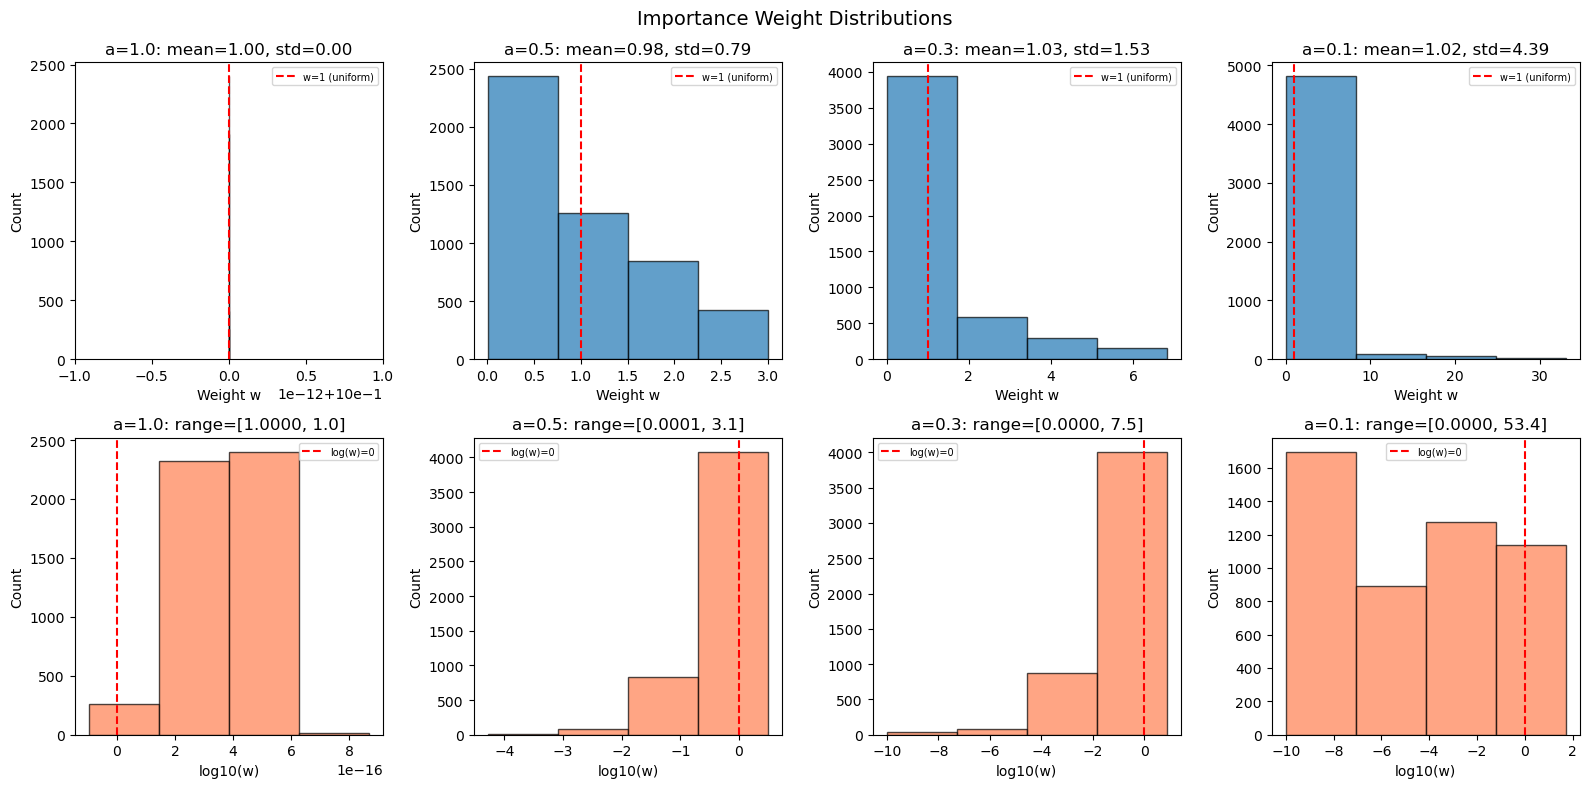

In [9]:
# Weight distributions
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 8))

set_seed(0)
for ai, alpha in enumerate(ALPHA_VALUES):
    n_vis = 5000
    rho, sigma = sample_from_proposal(n_vis, alpha, alpha, BETA_SIGMA, A)
    w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)

    # Weight histogram
    lo, hi = np.percentile(w, [0.5, 99.5])
    axes[0, ai].hist(w[(w >= lo) & (w <= hi)], bins=4, alpha=0.7, edgecolor='black')
    axes[0, ai].axvline(x=1.0, color='r', linestyle='--', label='w=1 (uniform)')
    axes[0, ai].set_xlabel('Weight w'); axes[0, ai].set_ylabel('Count')
    axes[0, ai].set_title(f'a={alpha}: mean={w.mean():.2f}, std={w.std():.2f}')
    axes[0, ai].legend(fontsize=7)

    # Log weight histogram
    log_w = np.log10(np.clip(w, 1e-10, None))
    axes[1, ai].hist(log_w, bins=4, alpha=0.7, edgecolor='black', color='coral')
    axes[1, ai].axvline(x=0, color='r', linestyle='--', label='log(w)=0')
    axes[1, ai].set_xlabel('log10(w)'); axes[1, ai].set_ylabel('Count')
    axes[1, ai].set_title(f'a={alpha}: range=[{w.min():.4f}, {w.max():.1f}]')
    axes[1, ai].legend(fontsize=7)

plt.suptitle('Importance Weight Distributions', fontsize=14)
plt.tight_layout(); plt.show()

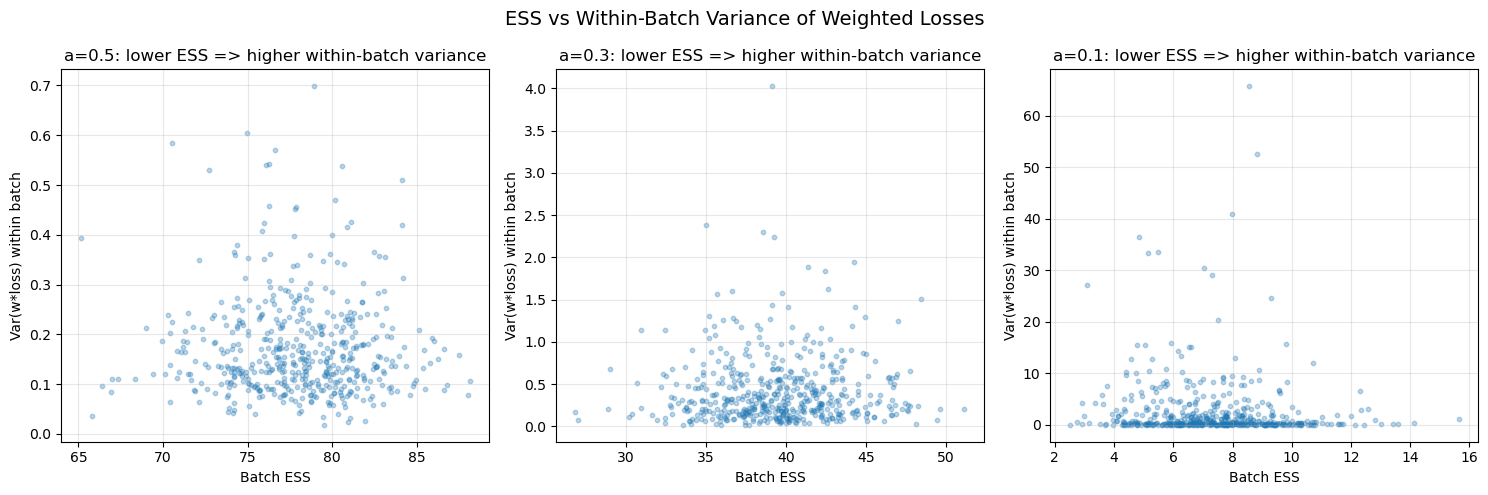

In [10]:
# ESS vs variance: scatter across batches
# For each batch k, we computed ESS and loss estimate. Show the relationship.
fig, axes = plt.subplots(1, len(ALPHA_VALUES)-1, figsize=(5*(len(ALPHA_VALUES)-1), 5))
if len(ALPHA_VALUES) - 1 == 1:
    axes = [axes]

set_seed(0)
for plot_idx, alpha in enumerate([a for a in ALPHA_VALUES if a != 1.0]):
    # Recompute per-batch ESS and loss estimates
    per_batch_ess = []
    per_batch_var_contrib = []

    for k in range(min(K, 500)):  # use subset for speed
        rho, sigma = sample_from_proposal(N, alpha, alpha, BETA_SIGMA, A, device=device)
        w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
        w_t = torch.tensor(w, dtype=torch.float32, device=device)

        wn = w / w.sum()
        ess = 1.0 / np.sum(wn**2)
        per_batch_ess.append(ess)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = ref_model(x)
        losses = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
        weighted = w_t * losses
        per_batch_var_contrib.append(weighted.var().item())

    axes[plot_idx].scatter(per_batch_ess, per_batch_var_contrib, alpha=0.3, s=10)
    axes[plot_idx].set_xlabel('Batch ESS')
    axes[plot_idx].set_ylabel('Var(w*loss) within batch')
    axes[plot_idx].set_title(f'a={alpha}: lower ESS => higher within-batch variance')
    axes[plot_idx].grid(True, alpha=0.3)

plt.suptitle('ESS vs Within-Batch Variance of Weighted Losses', fontsize=14)
plt.tight_layout(); plt.show()

## F. Batch Size Scaling

Theory predicts $\text{Var}(\hat{L}^{MC}) \propto 1/N$ for naive MC. For IS, the scaling is roughly $\text{Var}(\hat{L}^{IS}) \propto 1/\text{ESS}$, which can be much worse than $1/N$ when ESS $\ll N$.

We verify this by measuring estimator variance for different batch sizes $N \in \{32, 64, 128, 256, 512\}$.

Batch size scaling experiment...
  alpha=1.0: done
  alpha=0.5: done
  alpha=0.3: done
  alpha=0.1: done


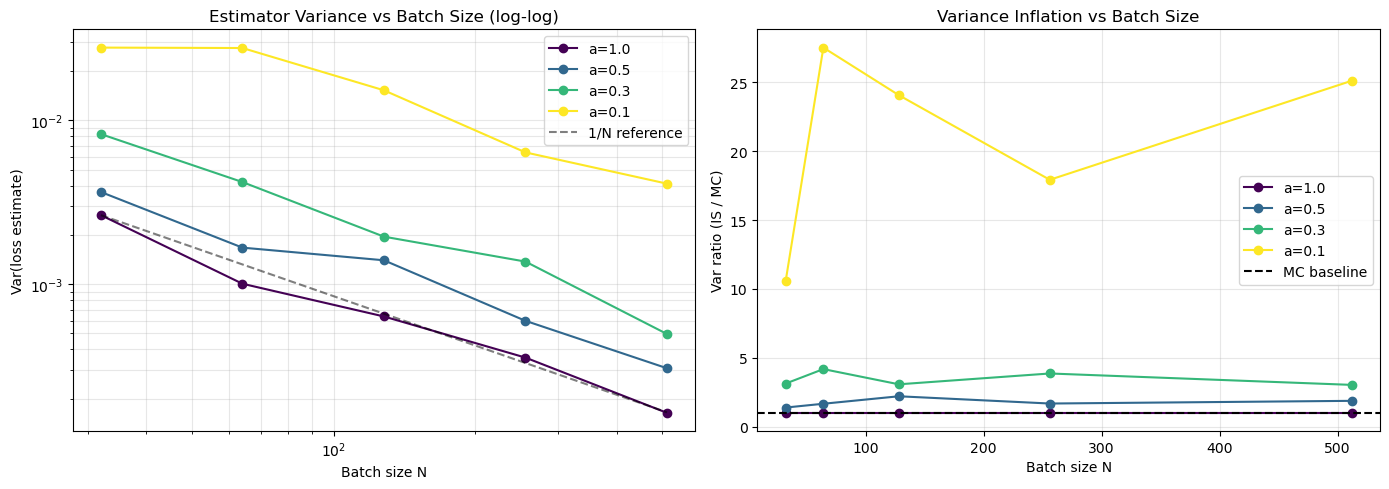

In [11]:
# Batch size scaling experiment
K_scale = 200  # estimates per condition (reduced for speed)

print("Batch size scaling experiment...")
scaling_results = {}  # [alpha][N] = variance

set_seed(0)
for alpha in ALPHA_VALUES:
    scaling_results[alpha] = {}
    for N_bs in BATCH_SIZES:
        estimates = []
        for k in range(K_scale):
            rho, sigma = sample_from_proposal(N_bs, alpha, alpha, BETA_SIGMA, A, device=device)
            w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
            w_t = torch.tensor(w, dtype=torch.float32, device=device)
            w_sn = w_t / w_t.sum()

            x = simulate_ar1_batch(rho, sigma, T, N_bs, device=device)
            with torch.no_grad():
                pred = ref_model(x)
            losses = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            estimates.append((w_sn * losses).sum().item())

        scaling_results[alpha][N_bs] = np.var(estimates)
    print(f"  alpha={alpha}: done")

# Plot: Var vs N (log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(ALPHA_VALUES)))

for ai, alpha in enumerate(ALPHA_VALUES):
    Ns = np.array(BATCH_SIZES)
    Vs = np.array([scaling_results[alpha][n] for n in BATCH_SIZES])
    axes[0].loglog(Ns, Vs, 'o-', color=colors[ai], label=f'a={alpha}')

# Reference: 1/N slope
Ns_ref = np.array(BATCH_SIZES)
V0 = scaling_results[1.0][BATCH_SIZES[0]]
ref_line = V0 * BATCH_SIZES[0] / Ns_ref
axes[0].loglog(Ns_ref, ref_line, 'k--', alpha=0.5, label='1/N reference')

axes[0].set_xlabel('Batch size N'); axes[0].set_ylabel('Var(loss estimate)')
axes[0].set_title('Estimator Variance vs Batch Size (log-log)')
axes[0].legend(); axes[0].grid(True, alpha=0.3, which='both')

# Variance ratio vs N
for ai, alpha in enumerate(ALPHA_VALUES):
    Vs = np.array([scaling_results[alpha][n] for n in BATCH_SIZES])
    V_mc = np.array([scaling_results[1.0][n] for n in BATCH_SIZES])
    axes[1].plot(BATCH_SIZES, Vs / V_mc, 'o-', color=colors[ai], label=f'a={alpha}')

axes[1].axhline(y=1.0, color='k', linestyle='--', label='MC baseline')
axes[1].set_xlabel('Batch size N'); axes[1].set_ylabel('Var ratio (IS / MC)')
axes[1].set_title('Variance Inflation vs Batch Size')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## G. Where Does the Variance Come From?

We decompose the parameter space into a $20 \times 20$ grid and compute the **per-bin contribution** to the total variance of $w \cdot \ell$. This reveals which regions of $(\rho, \sigma)$ space are responsible for the high variance under IS.

Bins where the weighted loss $w \cdot \ell$ varies most are the "problem spots" — these drive up the estimator variance.

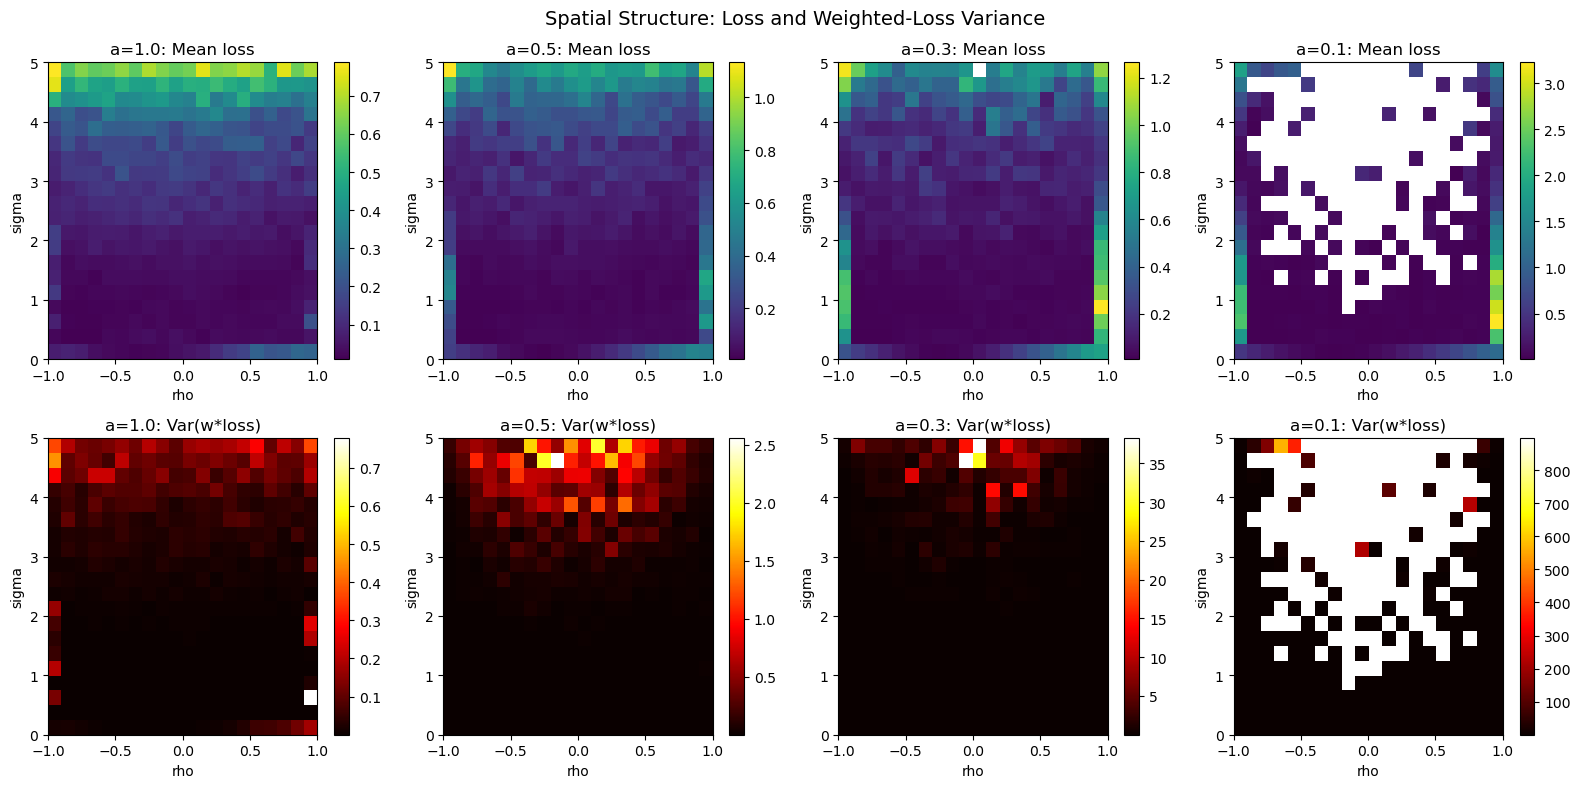

In [12]:
# Spatial analysis: where does variance come from?
N_BINS = 20

set_seed(0)
n_spatial = 20_000

fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 8))

for ai, alpha in enumerate(ALPHA_VALUES):
    rho, sigma = sample_from_proposal(n_spatial, alpha, alpha, BETA_SIGMA, A, device=device)
    w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
    w_t = torch.tensor(w, dtype=torch.float32, device=device)

    x = simulate_ar1_batch(rho, sigma, T, n_spatial, device=device)
    with torch.no_grad():
        pred = ref_model(x)
    losses = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1).cpu().numpy()

    rho_np = rho.cpu().numpy() if torch.is_tensor(rho) else rho
    sigma_np = sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma

    # Unweighted loss
    weighted_loss = w * losses

    rho_edges = np.linspace(-1, 1, N_BINS + 1)
    sigma_edges = np.linspace(0, A, N_BINS + 1)
    ri = np.clip(np.digitize(rho_np, rho_edges) - 1, 0, N_BINS - 1)
    si = np.clip(np.digitize(sigma_np, sigma_edges) - 1, 0, N_BINS - 1)

    # Mean loss per bin
    loss_grid = np.full((N_BINS, N_BINS), np.nan)
    wl_var_grid = np.full((N_BINS, N_BINS), np.nan)
    for r in range(N_BINS):
        for s in range(N_BINS):
            mask = (ri == r) & (si == s)
            if mask.sum() > 2:
                loss_grid[s, r] = np.mean(losses[mask])
                wl_var_grid[s, r] = np.var(weighted_loss[mask])

    im1 = axes[0, ai].imshow(loss_grid, origin='lower', aspect='auto',
                              extent=[-1, 1, 0, A], cmap='viridis')
    plt.colorbar(im1, ax=axes[0, ai])
    axes[0, ai].set_xlabel('rho'); axes[0, ai].set_ylabel('sigma')
    axes[0, ai].set_title(f'a={alpha}: Mean loss')

    im2 = axes[1, ai].imshow(wl_var_grid, origin='lower', aspect='auto',
                              extent=[-1, 1, 0, A], cmap='hot')
    plt.colorbar(im2, ax=axes[1, ai])
    axes[1, ai].set_xlabel('rho'); axes[1, ai].set_ylabel('sigma')
    axes[1, ai].set_title(f'a={alpha}: Var(w*loss)')

plt.suptitle('Spatial Structure: Loss and Weighted-Loss Variance', fontsize=14)
plt.tight_layout(); plt.show()

## H. Impact on Training

The variance of $\hat{L}^{IS}$ directly affects the **gradient signal** during training:

$$\nabla_\phi \hat{L}^{IS} = \frac{1}{N}\sum_i w_i \,\nabla_\phi \ell_i$$

Higher variance in the weighted loss $\Rightarrow$ noisier gradients $\Rightarrow$ potentially slower or less stable training.

We train multiple models with each proposal and examine:
1. Epoch-to-epoch test loss variability
2. Final performance spread across runs

In [13]:
# Train models with IS for each alpha (R=3 runs)
R = 3

def train_model_is(alpha, n_epochs, n_batches, batch_size, device, seed=42):
    set_seed(seed)
    model = GRUPosteriorEstimator(
        input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    train_losses, test_losses, batch_loss_vars = [], [], []

    set_seed(99999)
    rho_test = torch.empty(1024, device=device).uniform_(-1, 1)
    sigma_test = torch.empty(1024, device=device).uniform_(0, A)
    x_test = simulate_ar1_batch(rho_test, sigma_test, T, 1024, device=device)
    set_seed(seed)  # restore

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        batch_losses_this_epoch = []

        for _ in range(n_batches):
            rho, sigma = sample_from_proposal(
                batch_size, alpha, alpha, BETA_SIGMA, A, device=device)
            weights = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
            weights = torch.tensor(weights, dtype=torch.float32, device=device)
            weights = torch.nan_to_num(weights, nan=1.0, posinf=10.0, neginf=0.1)
            weights = torch.clamp(weights, min=0.1, max=10.0)
            w_norm = weights / weights.sum()

            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue
            theta_pred = model(x)
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue

            loss_per_sample = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = torch.sum(w_norm * loss_per_sample)
            if torch.isnan(loss) or torch.isinf(loss):
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            batch_losses_this_epoch.append(loss.item())

        train_losses.append(epoch_loss / n_batches)
        if batch_losses_this_epoch:
            batch_loss_vars.append(np.var(batch_losses_this_epoch))
        else:
            batch_loss_vars.append(0.0)

        model.eval()
        with torch.no_grad():
            pred_test = model(x_test)
            tl = ((pred_test - torch.stack([rho_test, sigma_test], dim=1))**2).mean().item()
            test_losses.append(tl)

    return model, train_losses, test_losses, batch_loss_vars

all_test_losses = {}
all_batch_vars = {}
all_models_is = {}

for alpha in ALPHA_VALUES:
    all_test_losses[alpha] = {}
    all_batch_vars[alpha] = {}
    all_models_is[alpha] = {}
    print(f"\nalpha={alpha}:")
    for run in range(R):
        seed = BASE_SEED + run
        print(f"  Run {run+1}/{R} (seed={seed})...", end=" ", flush=True)
        t0 = time.time()
        model, _, test_l, bvars = train_model_is(
            alpha, N_EPOCHS, N_BATCHES_PER_EPOCH, TRAINING_BATCH_SIZE, device, seed=seed)
        elapsed = time.time() - t0
        all_test_losses[alpha][run] = test_l
        all_batch_vars[alpha][run] = bvars
        all_models_is[alpha][run] = model
        print(f"done in {elapsed:.1f}s (final test MSE: {test_l[-1]:.4f})")

total_time_train = sum(time.time() - time.time() for _ in [])  # placeholder
print(f"\nAll {len(ALPHA_VALUES)*R} models trained.")


alpha=1.0:
  Run 1/3 (seed=42)... done in 36.8s (final test MSE: 0.0575)
  Run 2/3 (seed=43)... done in 36.6s (final test MSE: 0.0549)
  Run 3/3 (seed=44)... done in 40.1s (final test MSE: 0.0591)

alpha=0.5:
  Run 1/3 (seed=42)... done in 39.7s (final test MSE: 0.0888)
  Run 2/3 (seed=43)... done in 38.5s (final test MSE: 0.0563)
  Run 3/3 (seed=44)... done in 40.3s (final test MSE: 0.0966)

alpha=0.3:
  Run 1/3 (seed=42)... done in 39.4s (final test MSE: 0.0490)
  Run 2/3 (seed=43)... done in 48.8s (final test MSE: 0.0557)
  Run 3/3 (seed=44)... done in 50.9s (final test MSE: 0.0624)

alpha=0.1:
  Run 1/3 (seed=42)... done in 44.8s (final test MSE: 0.0973)
  Run 2/3 (seed=43)... done in 39.5s (final test MSE: 0.0744)
  Run 3/3 (seed=44)... done in 41.5s (final test MSE: 0.1075)

All 12 models trained.


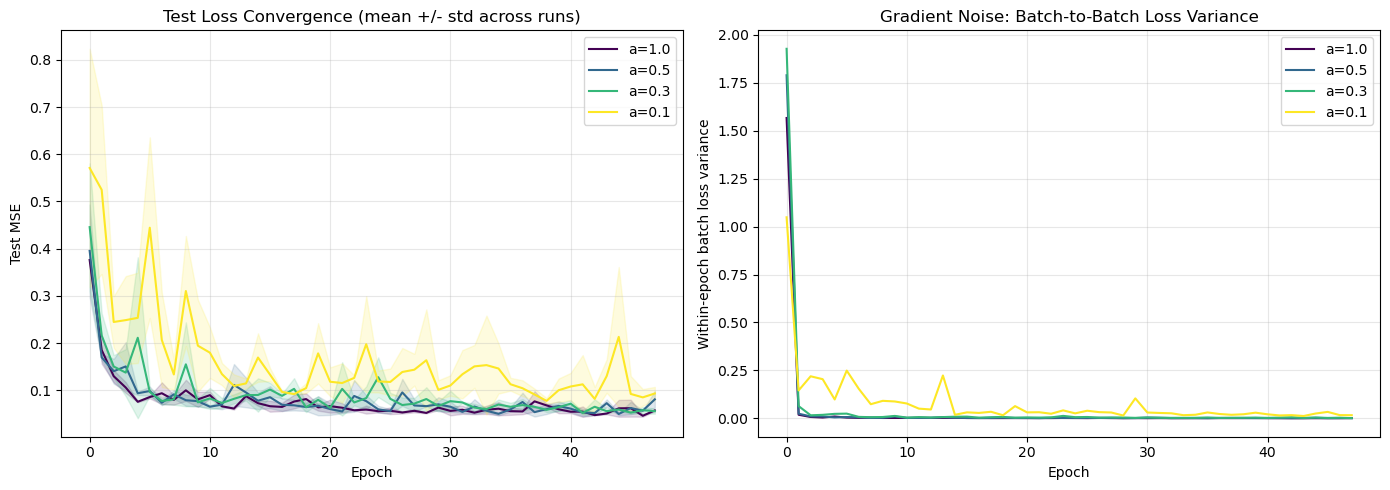


FINAL TEST MSE PER RUN
Alpha     Run 1       Run 2       Run 3       Mean        Std         
----------------------------------------------------------------------
a=1.0     0.0575      0.0549      0.0591      0.0572      0.0017      
a=0.5     0.0888      0.0563      0.0966      0.0806      0.0174      
a=0.3     0.0490      0.0557      0.0624      0.0557      0.0055      
a=0.1     0.0973      0.0744      0.1075      0.0931      0.0139      


In [14]:
# Training convergence: test loss with confidence bands
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(ALPHA_VALUES)))
epochs_arr = np.arange(N_EPOCHS)

for ai, alpha in enumerate(ALPHA_VALUES):
    test_arr = np.array([all_test_losses[alpha][r] for r in range(R)])
    mu, sd = test_arr.mean(axis=0), test_arr.std(axis=0)
    axes[0].plot(epochs_arr, mu, color=colors[ai], label=f'a={alpha}')
    axes[0].fill_between(epochs_arr, mu - sd, mu + sd, color=colors[ai], alpha=0.15)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test MSE')
axes[0].set_title('Test Loss Convergence (mean +/- std across runs)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Within-epoch batch loss variance
for ai, alpha in enumerate(ALPHA_VALUES):
    bv_arr = np.array([all_batch_vars[alpha][r] for r in range(R)])
    mu = bv_arr.mean(axis=0)
    axes[1].plot(epochs_arr, mu, color=colors[ai], label=f'a={alpha}')

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Within-epoch batch loss variance')
axes[1].set_title('Gradient Noise: Batch-to-Batch Loss Variance')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Final performance table
print("\n" + "="*70)
print("FINAL TEST MSE PER RUN")
print("="*70)
header = f"{'Alpha':<10}" + "".join(f"{'Run '+str(r+1):<12}" for r in range(R)) + f"{'Mean':<12}{'Std':<12}"
print(header)
print("-"*70)
for alpha in ALPHA_VALUES:
    final = [all_test_losses[alpha][r][-1] for r in range(R)]
    row = f"{'a='+str(alpha):<10}" + "".join(f"{l:<12.4f}" for l in final)
    row += f"{np.mean(final):<12.4f}{np.std(final):<12.4f}"
    print(row)
print("="*70)

In [15]:
# Evaluate all trained models on uniform test set
set_seed(0)
rho_eval = torch.empty(10_000, device=device).uniform_(-1, 1)
sigma_eval = torch.empty(10_000, device=device).uniform_(0, A)
x_eval = simulate_ar1_batch(rho_eval, sigma_eval, T, 10_000, device=device)

print("\n" + "="*70)
print("UNIFORM EVALUATION (10k test points)")
print("="*70)
print(f"{'Alpha':<10} {'Run MSEs':<40} {'Mean':<12}")
print("-"*70)

for alpha in ALPHA_VALUES:
    run_mses = []
    for run in range(R):
        all_models_is[alpha][run].eval()
        with torch.no_grad():
            pred = all_models_is[alpha][run](x_eval)
            mse = ((pred - torch.stack([rho_eval, sigma_eval], dim=1))**2).mean().item()
            run_mses.append(mse)
    mse_str = ", ".join(f"{m:.4f}" for m in run_mses)
    print(f"{'a='+str(alpha):<10} {mse_str:<40} {np.mean(run_mses):<12.4f}")
print("="*70)


UNIFORM EVALUATION (10k test points)
Alpha      Run MSEs                                 Mean        
----------------------------------------------------------------------
a=1.0      0.0573, 0.0558, 0.0596                   0.0576      
a=0.5      0.0830, 0.0570, 0.1006                   0.0802      
a=0.3      0.0507, 0.0591, 0.0673                   0.0590      
a=0.1      0.0982, 0.0779, 0.1202                   0.0988      


## I. Summary

In [16]:
# Summary
print("\n" + "="*70)
print("SUMMARY: IS LOSS ESTIMATOR VARIANCE")
print("="*70)

print(f"\nExperiment: K={K} independent loss estimates, N={N} per batch")
print(f"Reference model trained with uniform sampling (alpha=1.0)")

print(f"\nVariance ratios (IS / MC) for self-normalised estimator:")
mc_var = loss_estimates[1.0]['self_norm'].var()
for alpha in ALPHA_VALUES:
    v = loss_estimates[alpha]['self_norm'].var()
    ratio = v / mc_var
    direction = "REDUCES" if ratio < 1 else "INCREASES"
    print(f"  alpha={alpha}: {ratio:.2f}x  -- IS {direction} variance")

print(f"\nTheoretical ESS fractions:")
for alpha in ALPHA_VALUES:
    print(f"  alpha={alpha}: ESS/N = {theoretical_ess[alpha]:.4f}")

print(f"\nKey insight:")
print(f"  The variance ratio roughly tracks 1/(ESS/N).")
print(f"  More aggressive IS (lower alpha) => lower ESS => higher variance.")
print(f"  Weight clipping and self-normalisation partially mitigate this,")
print(f"  but cannot fully compensate for the loss of effective samples.")

print(f"\n" + "="*70)


SUMMARY: IS LOSS ESTIMATOR VARIANCE

Experiment: K=500 independent loss estimates, N=128 per batch
Reference model trained with uniform sampling (alpha=1.0)

Variance ratios (IS / MC) for self-normalised estimator:
  alpha=1.0: 1.00x  -- IS INCREASES variance
  alpha=0.5: 2.14x  -- IS INCREASES variance
  alpha=0.3: 4.05x  -- IS INCREASES variance
  alpha=0.1: 27.42x  -- IS INCREASES variance

Theoretical ESS fractions:
  alpha=1.0: ESS/N = 1.0000
  alpha=0.5: ESS/N = 0.6090
  alpha=0.3: ESS/N = 0.3076
  alpha=0.1: ESS/N = 0.0481

Key insight:
  The variance ratio roughly tracks 1/(ESS/N).
  More aggressive IS (lower alpha) => lower ESS => higher variance.
  Weight clipping and self-normalisation partially mitigate this,
  but cannot fully compensate for the loss of effective samples.

